In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import itertools

from smt.sampling_methods import LHS
from smt.surrogate_models import MixIntKernelType

from comcatalyst.vars.var_metadata import VarMetadata
from comcatalyst.vars.vars_metadata import VarsMetadata
from comcatalyst.xprs.fn_objectives import calc_gp_objective_01
from comcatalyst.xprs.xpr_moda import XPRModA
from comcatalyst.xprs.visualizations import (
    plot_comparison_convergence, 
    plot_gp_quant_by_qual, 
    plot_3d_gp_quant_by_qual,
    plot_ground_truth,
    plot_3d_ground_truth
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **XPR**

In [ ]:
# Variables
vars_metadata = VarsMetadata([
    VarMetadata(name="x_qual1",  var_type="categorical", support=["A","B"]),
    VarMetadata(name="x_qual2",  var_type="categorical", support=["alpha","beta"]),
    VarMetadata(name="x_quant1", var_type="continuous",  support=(-1, 1)),
    VarMetadata(name="x_quant2", var_type="continuous",  support=(-1, 1)),
])

z = {"z1": 1.0, "z2": 1.0}

In [ ]:
# Hyperparameters
fn_gp_objective = lambda x, vars_metadata, z, sigma_noise, rng=None: calc_gp_objective_01(
    x=x,
    vars_metadata=vars_metadata,
    z=z,
    sigma_noise=sigma_noise,
    rng=rng,
    _SCALE_Q1={0: 2, 1: 2},
    _SCALE_Q2={0: 2, 1: 2},
)

n_init = 5
n_iter_bo = 10
n_start = 20
sampling_method = LHS
sampling_criterion = "ese"
kernel = MixIntKernelType.CONT_RELAX
bo_criterion = "EI"
sigma_noise = 0.1
qei="KBLB"
seed = 0
seed_ydoe_offset = 1000

In [ ]:
# True max
x_true_max, y_true_max, X_grid, Y_grid = XPRModA.calc_true_max(
    fn_gp_objective=fn_gp_objective, 
    vars_metadata=vars_metadata, 
    z=z, 
    n_grille=1000
)

XPRModA.print_opt_result(x=x_true_max, y=y_true_max, vars_metadata=vars_metadata)

  x* = x_qual1 = A / x_qual2 = alpha / x_quant1 = 0.4935 / x_quant2 = 0.9980
  y* = 5.2992


In [ ]:
# Check répartition maxima
categ_combos = list(itertools.product(
    vars_metadata[0].support, # qual1
    vars_metadata[1].support, # qual2
))

for combo in categ_combos:
    mask = (
        (X_grid[:, 0] == vars_metadata[0].support.index(combo[0])) &
        (X_grid[:, 1] == vars_metadata[1].support.index(combo[1]))
    )
    y_combo = Y_grid[mask]
    combo_label = f"{combo[0]}/{combo[1]}"
    print(
        f"{combo_label:<8} :  "
        f"max ={y_combo.max():6.3f}   "
        f"min ={y_combo.min():7.3f}   "
        f"mean ={y_combo.mean():6.3f}   "
        f"% > 0.8*max ={100*(y_combo > 0.8*Y_grid.max()).mean():5.1f}%"
    )

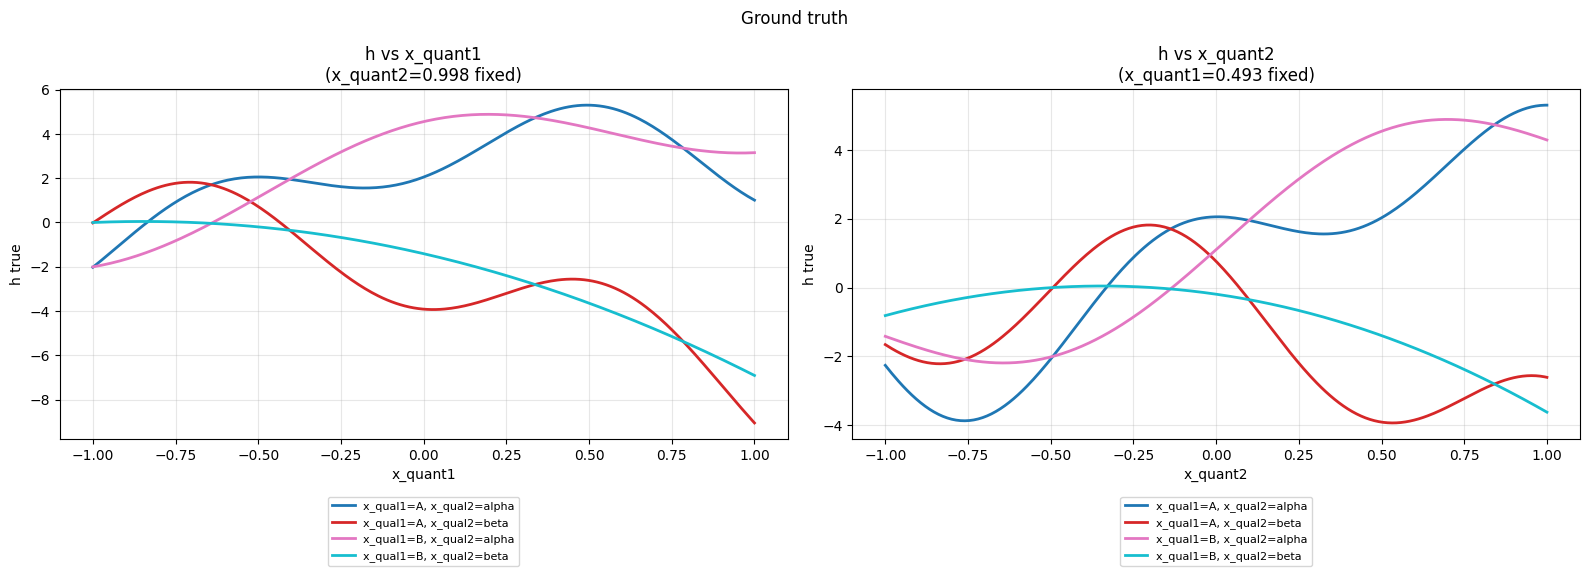

In [24]:
# Plot true max 2d
plot_ground_truth(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    quant_fixed_vals=(
        (2, x_true_max[2]), 
        (3, x_true_max[3])
    ),
    n_points=300,
    figsize=(8,6)
)

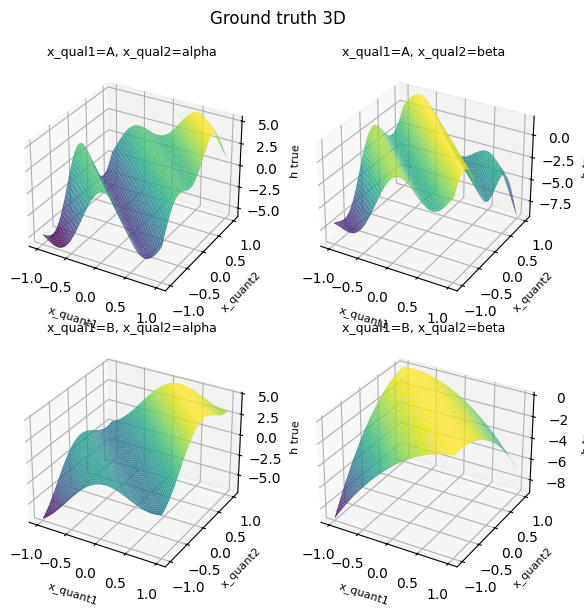

In [25]:
# PLot true max 3d
plot_3d_ground_truth(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    quant_idx_1=2,
    quant_idx_2=3,
    n_points=300,
    n_cols=2,
    figsize=(3,3)    
)


In [ ]:
# EGO
seed = 0
design_space = XPRModA.create_smt_design_space(
    vars_metadata=vars_metadata,
    sampling_method=sampling_method,
    sampling_criterion=sampling_criterion,
    seed=seed
)

x_init = XPRModA.calc_x_init(
    n_init=n_init,
    design_space=design_space,
    sampling_method=sampling_method,
    sampling_criterion=sampling_criterion,
    seed=seed
)

y_init = XPRModA.calc_y_objective_for_ego(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    x=x_init, 
    z=z,
    sigma_noise=sigma_noise, 
    rng=np.random.default_rng(1+seed_ydoe_offset) # ou 0+offset
)

res_ego = XPRModA.run_ego(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    design_space=design_space,
    x_init=x_init,
    y_init=y_init,
    z=z,
    n_iter_bo=n_iter_bo,
    kernel=kernel,
    bo_criterion=bo_criterion,
    qei=qei,
    sigma_noise=sigma_noise,
    n_start=n_start,
    seed=1
)

In [27]:
# EGO results details
print(f"--- BO x_data ---\n{res_ego.x_data}")
print(f"\n--- BO y_data ---\n{res_ego.y_data}")

print("\n--- Results ---")
XPRModA.print_opt_result(x=res_ego.x_opt, y=res_ego.y_opt, vars_metadata=vars_metadata)

--- BO x_data ---
[[ 0.          1.          0.46824977  0.86018371]
 [ 0.          0.          0.87421679 -0.63489777]
 [ 1.          1.         -0.27365858  0.01658449]
 [ 1.          0.         -0.6746919   0.4588758 ]
 [ 0.          1.          0.14527157 -0.5989046 ]
 [ 1.          0.          1.          0.76673804]
 [ 1.          0.          0.70009315  0.17655875]
 [ 1.          0.          0.53115584  1.        ]
 [ 1.          0.          0.46501427 -1.        ]
 [ 0.          0.          0.64476748  0.62530575]
 [ 1.          0.          0.6273463   0.63060024]
 [ 1.          0.          0.46709032  0.54817931]
 [ 0.          1.         -1.          1.        ]
 [ 1.          1.         -1.         -1.        ]
 [ 0.          0.         -1.         -1.        ]]

--- BO y_data ---
[[-2.82682825]
 [ 0.83393539]
 [-0.28611355]
 [-2.15619215]
 [-1.94463502]
 [ 3.39516594]
 [ 4.01138276]
 [ 4.15869768]
 [-1.31992643]
 [ 4.24375414]
 [ 4.85016331]
 [ 4.61236999]
 [ 0.        ]
 [

In [28]:
# Check repartition qualitative variables
for q1 in [0, 1]:
    for q2 in [0, 1]:
        mask = (res_ego.x_data[:n_init,0]==q1) & (res_ego.x_data[:n_init,1]==q2)
        print(f"qual1={q1} qual2={q2}: {mask.sum()} points")

qual1=0 qual2=0: 1 points
qual1=0 qual2=1: 2 points
qual1=1 qual2=0: 1 points
qual1=1 qual2=1: 1 points


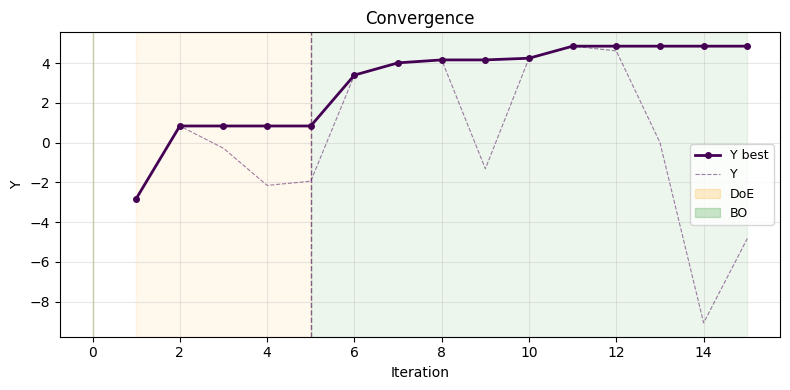

In [29]:
# Plot convergence
plot_comparison_convergence(
    y_datas=[res_ego.y_data],
    n_init=n_init,
)

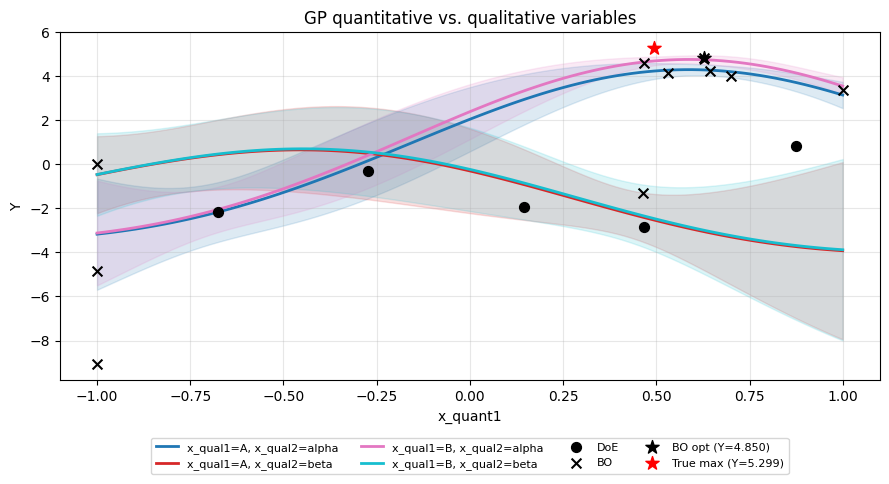

In [30]:
# Plot quant1 by qual
plot_gp_quant_by_qual(
    sm=res_ego.sm,
    vars_metadata=vars_metadata,
    x_opt=res_ego.x_opt,
    quant_to_variate_idx=2,
    reverse_optim=True,
    qual_filter=[(0, ["A", "B"]), (1, ["alpha", "beta"])],
    x_data=res_ego.x_data,
    y_data=res_ego.y_data,
    n_init=n_init,
    y_opt=res_ego.y_opt,
    x_true_max=x_true_max,
    y_true_max=y_true_max,
    figsize=(9,5)
)

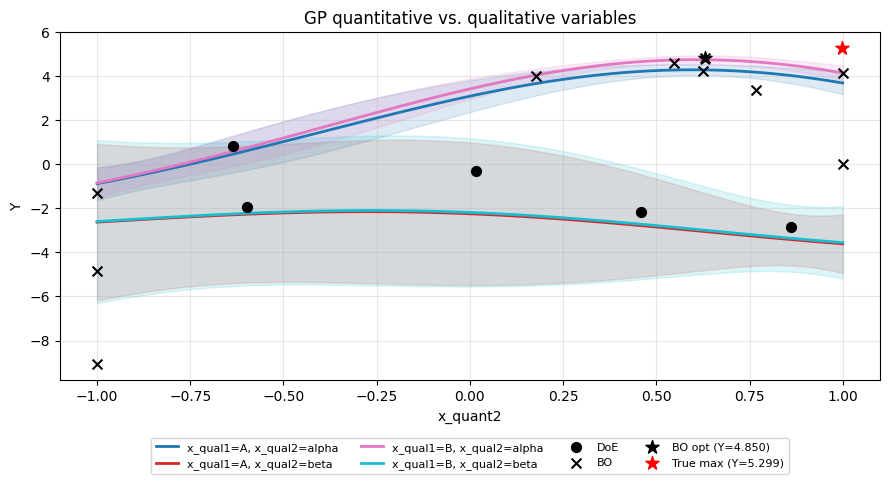

In [31]:
# Plot quant2 by qual
plot_gp_quant_by_qual(
    sm=res_ego.sm,
    vars_metadata=vars_metadata,
    x_opt=res_ego.x_opt,
    quant_to_variate_idx=3,
    reverse_optim=True,
    qual_filter=[(0, ["A", "B"]), (1, ["alpha", "beta"])],
    x_data=res_ego.x_data,
    y_data=res_ego.y_data,
    n_init=n_init,
    y_opt=res_ego.y_opt,
    x_true_max=x_true_max,
    y_true_max=y_true_max,
    figsize=(9,5)    
)

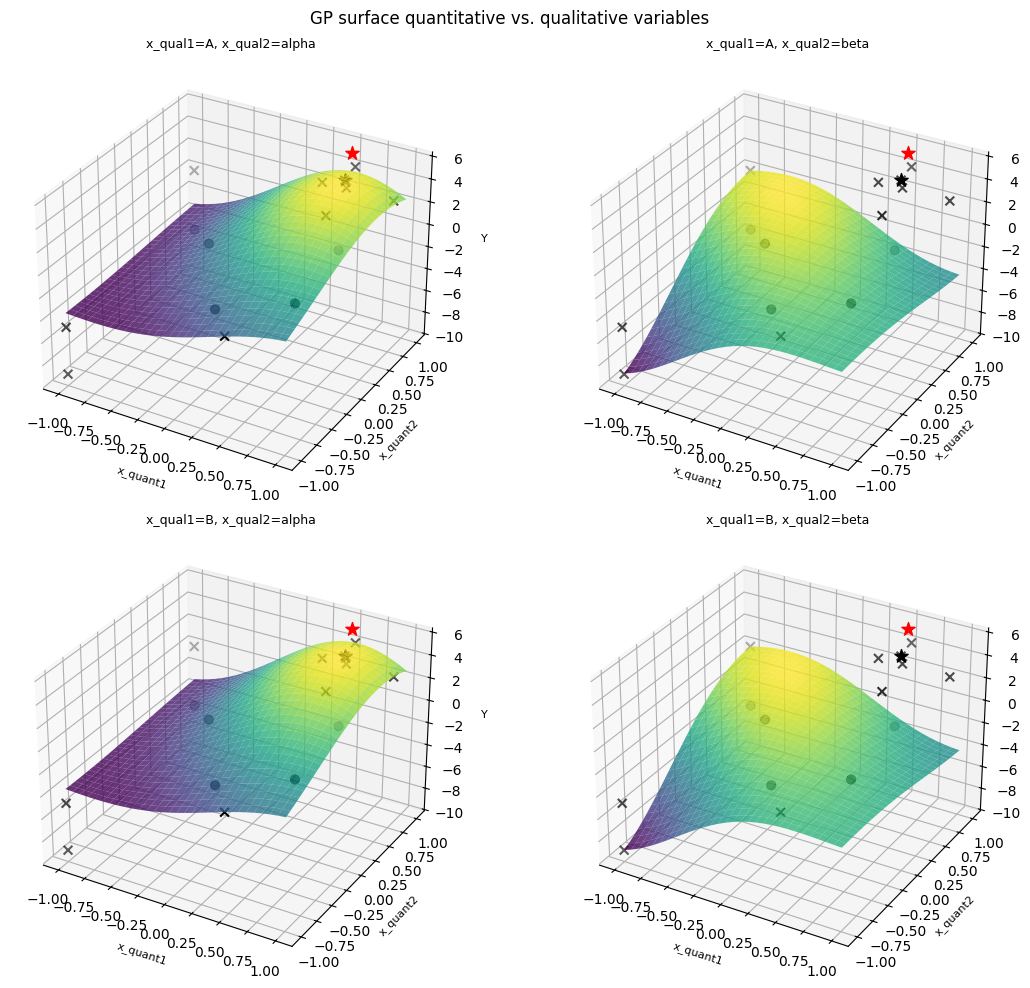

In [32]:
# Plot 3d
plot_3d_gp_quant_by_qual(
    sm=res_ego.sm,
    vars_metadata=vars_metadata,
    x_opt=res_ego.x_opt,
    quant_to_variate_idx_1=2,
    quant_to_variate_idx_2=3,
    reverse_optim=True,
    qual_filter=None,
    x_data=res_ego.x_data,
    y_data=res_ego.y_data,
    n_init=n_init,
    y_opt=res_ego.y_opt,
    x_true_max=x_true_max,
    y_true_max=y_true_max,
    n_cols=2
)